# 05 - Metricas e comparacao final

Usa o **autoencoder ja treinado** (`models/autoencoder_bottle_best.pth`) e as **mascaras de ground-truth** do MVTec para calcular as metricas de localizacao do enunciado, e termina com a **comparacao final dos 3 modelos**:

- **Image-level AUROC** (deteta se a imagem tem defeito)
- **Pixel-level AUROC** (deteta *onde* esta o defeito)
- **IoU / Dice** da localizacao
- **Falsos positivos por categoria**

Ideia: o **mapa de erro de reconstrucao** (por pixel) funciona como mapa de anomalia; comparado com a mascara real, da as metricas de localizacao.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torchvision import transforms
from sklearn.metrics import roc_auc_score

from autoencoder import Autoencoder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("A usar:", device)

# Carrega o autoencoder treinado
modelo = Autoencoder().to(device)
modelo.load_state_dict(torch.load("../models/autoencoder_bottle_best.pth", map_location=device))
modelo.eval()
print("Modelo carregado.")

A usar: cuda


Modelo carregado.


## 1. Calcular os mapas de erro e carregar as mascaras

Para cada imagem de teste: passa pelo autoencoder, calcula o erro por pixel (`(orig - reconstrucao)^2`, media dos canais) e carrega a mascara real (zeros para imagens `good`).

In [2]:
T = 256
img_tf = transforms.Compose([
    transforms.Resize((T, T)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

root = Path("../data/mvtec/bottle")
test_dir = root / "test"
gt_dir = root / "ground_truth"

img_scores, img_labels, img_cats = [], [], []
pixel_scores_list, pixel_labels_list = [], []
error_maps, masks_all, originais, cats_all = [], [], [], []

for sub in sorted(test_dir.iterdir()):
    if not sub.is_dir():
        continue
    cat = sub.name
    label = 0 if cat == "good" else 1
    for p in sorted(sub.glob("*.png")):
        img = Image.open(p).convert("RGB")
        x = img_tf(img).unsqueeze(0).to(device)
        with torch.no_grad():
            rec = modelo(x)
        err = ((rec - x) ** 2).mean(dim=1).squeeze(0).cpu().numpy()  # mapa HxW

        if label == 0:
            mask = np.zeros((T, T), dtype=np.uint8)
        else:
            mp = gt_dir / cat / (p.stem + "_mask.png")
            m = Image.open(mp).convert("L").resize((T, T))
            mask = (np.array(m) > 0).astype(np.uint8)

        img_scores.append(float(err.mean()))
        img_labels.append(label)
        img_cats.append(cat)
        pixel_scores_list.append(err.ravel())
        pixel_labels_list.append(mask.ravel())
        error_maps.append(err)
        masks_all.append(mask)
        originais.append(np.array(img.resize((T, T))))
        cats_all.append(cat)

img_scores = np.array(img_scores)
img_labels = np.array(img_labels)
img_cats = np.array(img_cats)
pixel_scores = np.concatenate(pixel_scores_list)
pixel_labels = np.concatenate(pixel_labels_list)

print("Imagens processadas:", len(img_scores))
print("Pixels no total:", pixel_scores.shape[0])

Imagens processadas: 83
Pixels no total: 5439488


## 2. Image-level e Pixel-level AUROC

In [3]:
auroc_img = roc_auc_score(img_labels, img_scores)
auroc_pix = roc_auc_score(pixel_labels, pixel_scores)

print(f"Image-level AUROC: {auroc_img:.4f}")
print(f"Pixel-level AUROC: {auroc_pix:.4f}")

Image-level AUROC: 0.9206
Pixel-level AUROC: 0.7952


## 3. Localizacao: IoU e Dice

Binariza o mapa de erro com um threshold e compara com a mascara real. Varremos varios thresholds e escolhemos o que maximiza o Dice.

In [4]:
thresholds = np.quantile(pixel_scores, np.linspace(0.90, 0.999, 30))
melhor = None  # (threshold, iou, dice)

for th in thresholds:
    pred = (pixel_scores >= th).astype(np.uint8)
    inter = int((pred & pixel_labels).sum())
    union = int((pred | pixel_labels).sum())
    soma = int(pred.sum() + pixel_labels.sum())
    iou = inter / union if union > 0 else 0.0
    dice = 2 * inter / soma if soma > 0 else 0.0
    if melhor is None or dice > melhor[2]:
        melhor = (th, iou, dice)

th_pixel, iou_best, dice_best = melhor
print(f"Melhor threshold: {th_pixel:.5f}")
print(f"IoU:  {iou_best:.4f}")
print(f"Dice: {dice_best:.4f}")

Melhor threshold: 0.04740
IoU:  0.1817
Dice: 0.3075


## 4. Falsos positivos por categoria

Definimos o threshold de deteccao (a nivel de imagem) no **percentil 95 do erro das imagens normais** (`good`) - ou seja, deixamos ~5% de falsos alarmes por design. Depois vemos, por categoria, quantas imagens sao marcadas como defeito.

In [5]:
th_img = np.quantile(img_scores[img_labels == 0], 0.95)
print(f"Threshold (imagem) = {th_img:.5f}\n")

for cat in ["good", "broken_large", "broken_small", "contamination"]:
    m = img_cats == cat
    n = int(m.sum())
    det = int((img_scores[m] >= th_img).sum())
    if cat == "good":
        print(f"{cat:14s}: {det}/{n} marcadas como defeito  <- FALSOS POSITIVOS")
    else:
        print(f"{cat:14s}: {det}/{n} detetadas como defeito")

Threshold (imagem) = 0.01819

good          : 1/20 marcadas como defeito  <- FALSOS POSITIVOS
broken_large  : 19/20 detetadas como defeito
broken_small  : 16/22 detetadas como defeito
contamination : 14/21 detetadas como defeito


## 5. Visualizacao: original / mapa de erro / mascara prevista / mascara real

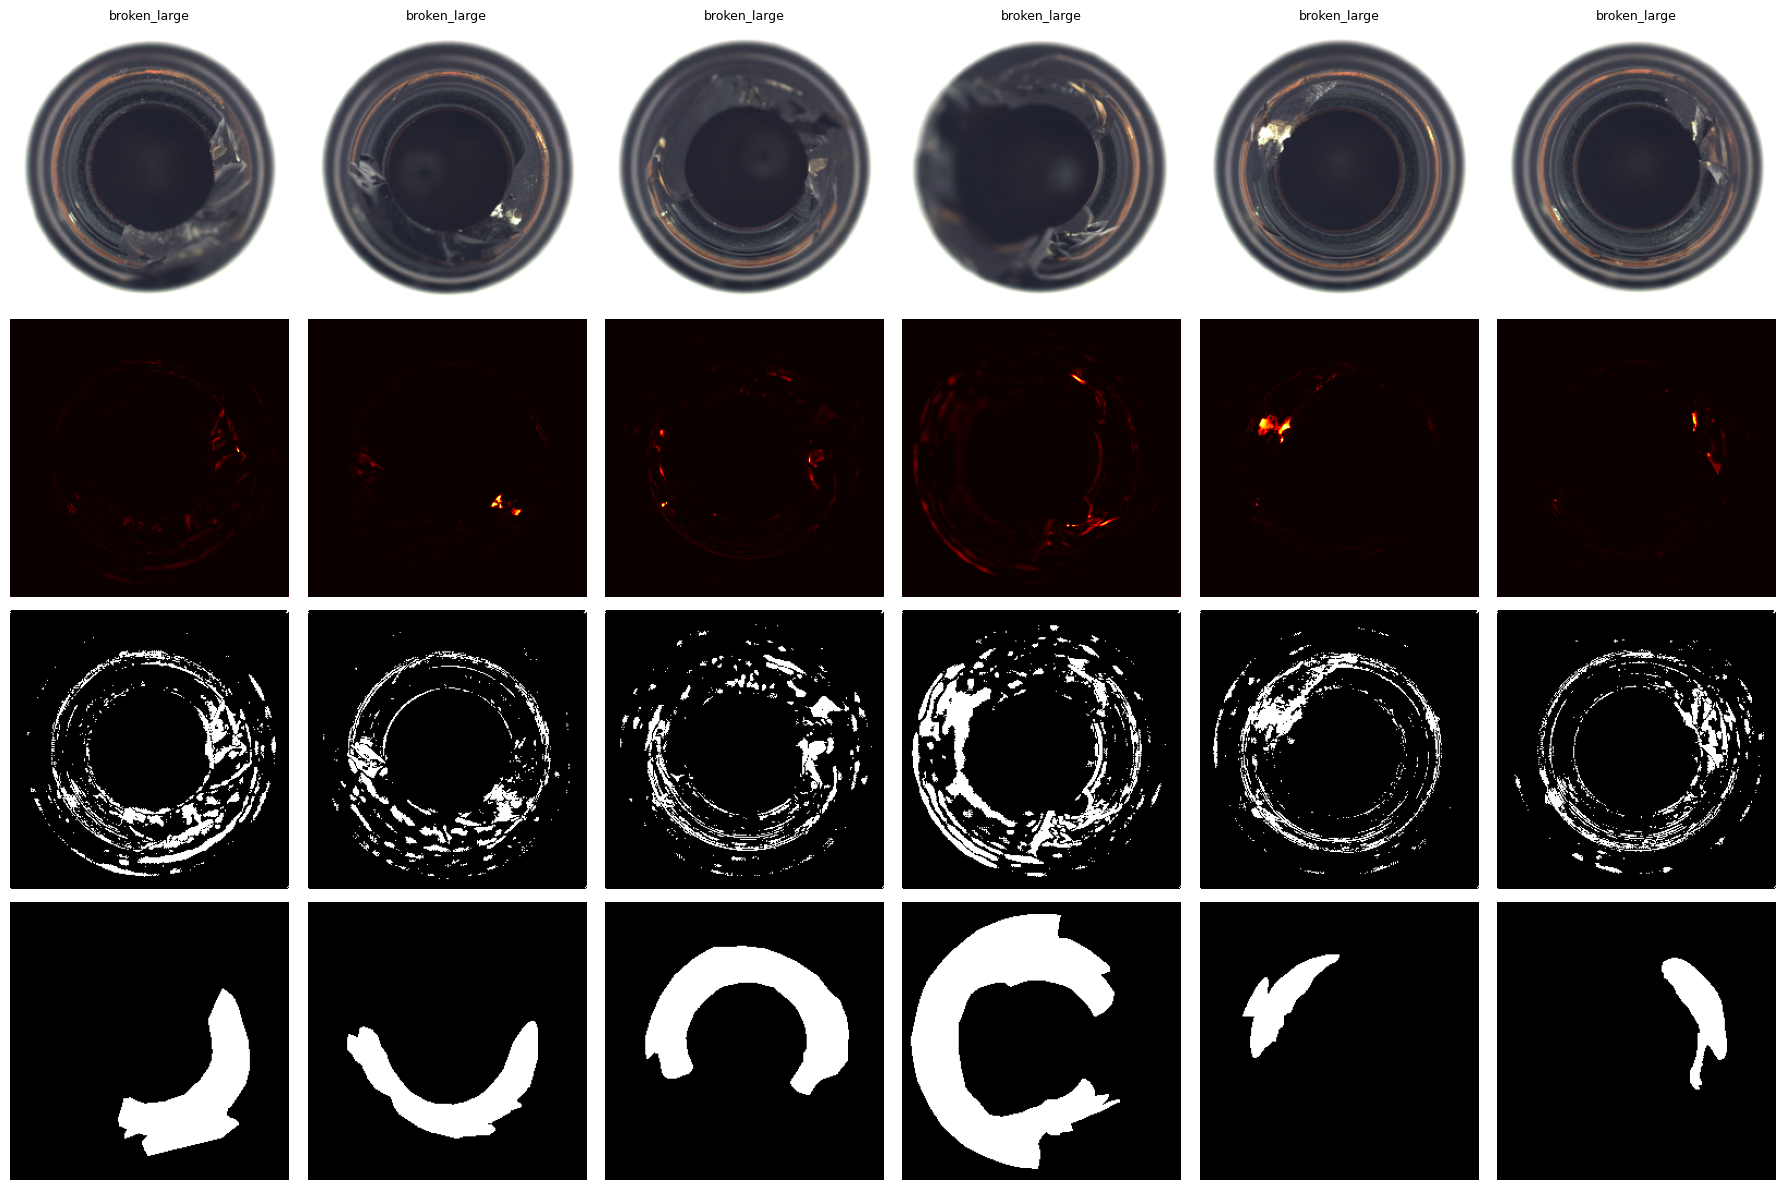

In [6]:
# Escolhe alguns exemplos defeituosos
idx_def = [i for i in range(len(cats_all)) if cats_all[i] != "good"][:6]

fig, axes = plt.subplots(4, len(idx_def), figsize=(3 * len(idx_def), 12))
linhas = ["Original", "Mapa de erro", "Mascara prevista", "Mascara real"]

for col, i in enumerate(idx_def):
    pred_mask = (error_maps[i] >= th_pixel).astype(np.uint8)
    axes[0, col].imshow(originais[i]); axes[0, col].set_title(cats_all[i], fontsize=9)
    axes[1, col].imshow(error_maps[i], cmap="hot")
    axes[2, col].imshow(pred_mask, cmap="gray")
    axes[3, col].imshow(masks_all[i], cmap="gray")
    for linha in range(4):
        axes[linha, col].axis("off")

for linha, nome in enumerate(linhas):
    axes[linha, 0].set_ylabel(nome, fontsize=11)

plt.tight_layout()
plt.show()

## 6. Comparacao final dos 3 metodos

Resumo de todo o projeto (Project 2 - MVTec AD, categoria `bottle`).

**Deteccao a nivel de imagem:**

| Modelo | Tipo | Metrica |
|---|---|---|
| Autoencoder (reconstrucao) | nao supervisionado | Image-AUROC **0.92** |
| CNN classifier | supervisionado | Accuracy **0.93** |
| ResNet + Mahalanobis | nao supervisionado (features pre-treinadas) | Image-AUROC **~1.00** |

**Localizacao do defeito (autoencoder, seccoes acima):**

| Metrica | Valor |
|---|---|
| Pixel-level AUROC | ~0.80 |
| IoU | ~0.18 |
| Dice | ~0.31 |
| Falsos positivos (imagens normais) | ~1/20 |

**Conclusao:** as abordagens **nao supervisionadas** (autoencoder e, sobretudo, ResNet+Mahalanobis) detetam bem *se* ha defeito sem precisar de exemplos defeituosos - ideal em inspecao industrial real, onde os defeitos sao raros. O **classificador supervisionado** tambem funciona bem, mas depende de ter defeitos rotulados (aqui so ~63). A **localizacao fina** (pixel/IoU) e o ponto mais fraco do autoencoder simples.